In [300]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

In [233]:
My_DF = pd.read_csv(r"D:\health_lifestyle_classification.csv")
df1 = pd.read_csv(r"D:\preprocessed_data1.csv")

In [234]:
My_DF.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996    False
99997    False
99998    False
99999    False
Length: 100000, dtype: bool

In [235]:
My_DF.shape

(100000, 48)

In [236]:
My_DF.isnull().sum()

survey_code                     0
age                             0
gender                          0
height                          0
weight                          0
bmi                             0
bmi_estimated                   0
bmi_scaled                      0
bmi_corrected                   0
waist_size                      0
blood_pressure               7669
heart_rate                  14003
cholesterol                     0
glucose                         0
insulin                     15836
sleep_hours                     0
sleep_quality                   0
work_hours                      0
physical_activity               0
daily_steps                  8329
calorie_intake                  0
sugar_intake                    0
alcohol_consumption         42387
smoking_level                   0
water_intake                    0
screen_time                     0
stress_level                    0
mental_health_score             0
mental_health_support           0
education_leve

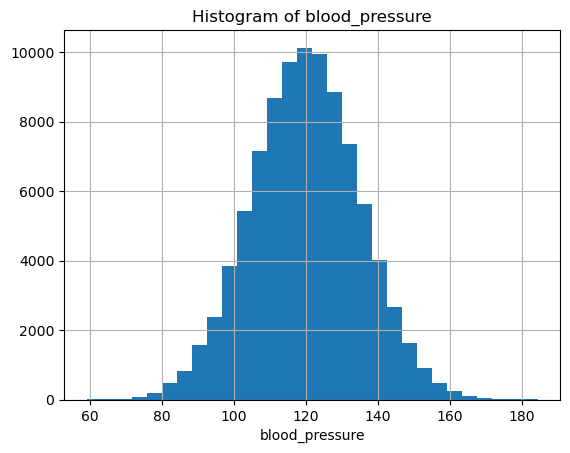

In [237]:
plt.figure()
My_DF["blood_pressure"].hist(bins=30)
plt.xlabel("blood_pressure")
plt.title("Histogram of " + "blood_pressure")
plt.show()

In [238]:
My_DF['blood_pressure']=My_DF['blood_pressure'].fillna(My_DF['blood_pressure'].mean())

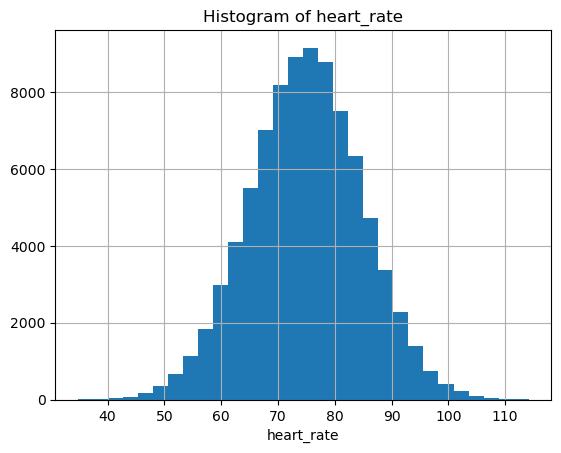

In [239]:
plt.figure()
My_DF["heart_rate"].hist(bins=30)
plt.xlabel("heart_rate")
plt.title("Histogram of " + "heart_rate")
plt.show()

In [240]:
My_DF['heart_rate']=My_DF['heart_rate'].fillna(My_DF['heart_rate'].mean())

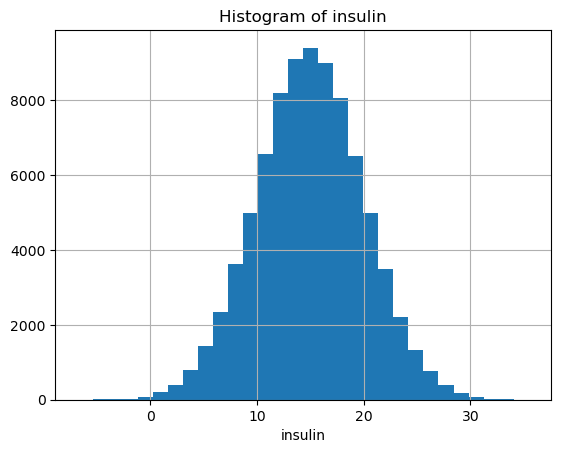

In [241]:
plt.figure()
My_DF["insulin"].hist(bins=30)
plt.xlabel("insulin")
plt.title("Histogram of " + "insulin")
plt.show()

In [242]:
My_DF['insulin']=My_DF['insulin'].fillna(My_DF['insulin'].mean())

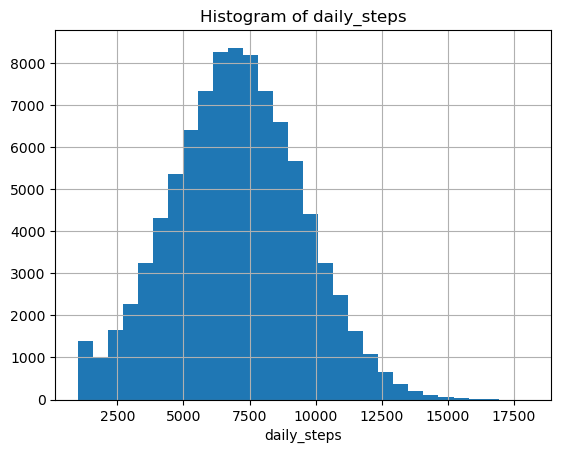

In [243]:
plt.figure()
My_DF["daily_steps"].hist(bins=30)
plt.xlabel("daily_steps")
plt.title("Histogram of " + "daily_steps")
plt.show()

In [244]:
My_DF['daily_steps']=My_DF['daily_steps'].fillna(My_DF['daily_steps'].median())

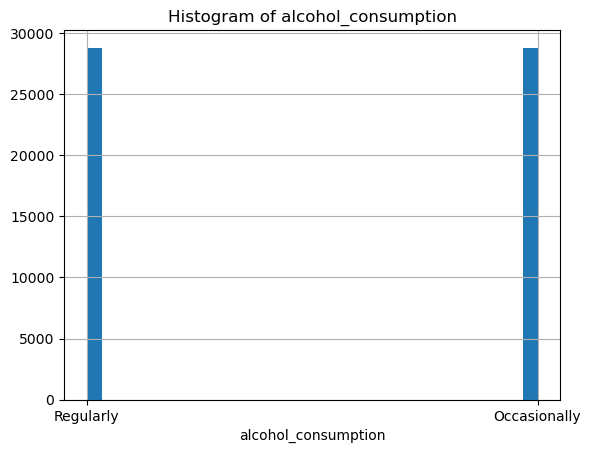

In [245]:
plt.figure()
My_DF["alcohol_consumption"].hist(bins=30)
plt.xlabel("alcohol_consumption")
plt.title("Histogram of " + "alcohol_consumption")
plt.show()

In [246]:
My_DF["alcohol_consumption"].value_counts()

alcohol_consumption
Occasionally    28831
Regularly       28782
Name: count, dtype: int64

In [247]:
My_DF['alcohol_consumption'] = (My_DF['alcohol_consumption'].map({'Regularly': 1, 'Occasionally': 0}).astype('Int64'))

In [248]:
col = 'alcohol_consumption'
counts = My_DF[col].value_counts()
total_non_null = counts.sum()
values = counts.index.tolist()
probs = (counts / total_non_null).tolist()
null_idx = My_DF[My_DF[col].isnull()].index
My_DF.loc[null_idx, col] = np.random.choice(values, size=len(null_idx), p=probs)
print(My_DF[col].value_counts())

alcohol_consumption
1    50009
0    49991
Name: count, dtype: Int64


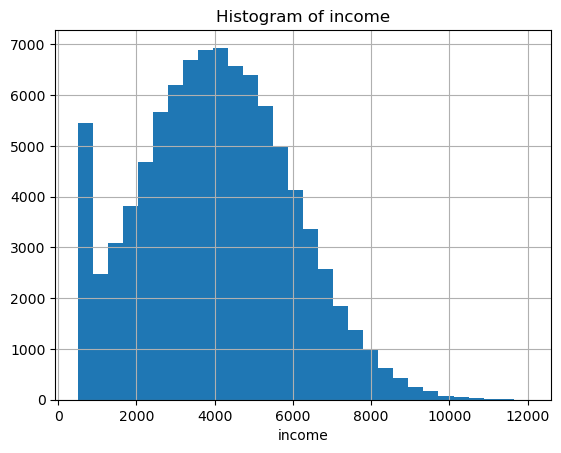

In [249]:
plt.figure()
My_DF["income"].hist(bins=30)
plt.xlabel("income")
plt.title("Histogram of " + "income")
plt.show()

In [250]:
My_DF['income']=My_DF['income'].fillna(My_DF['income'].median())

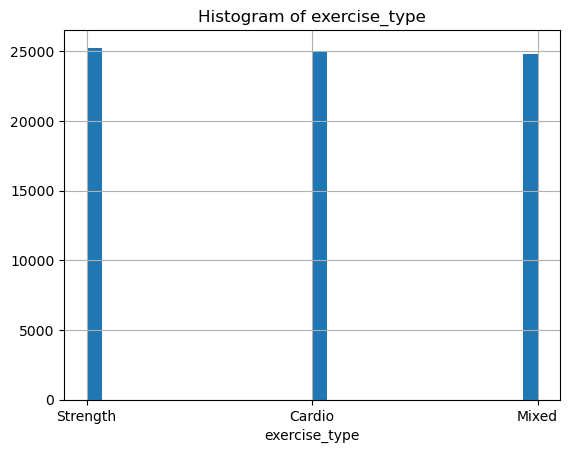

In [251]:
plt.figure()
My_DF["exercise_type"].hist(bins=30)
plt.xlabel("exercise_type")
plt.title("Histogram of " + "exercise_type")
plt.show()

In [252]:
My_DF["exercise_type"].value_counts()

exercise_type
Strength    25265
Cardio      24988
Mixed       24778
Name: count, dtype: int64

In [253]:
col = 'exercise_type'
counts = My_DF[col].value_counts()
total_non_null = counts.sum()
values = counts.index.tolist()
probs = (counts / total_non_null).tolist()
null_idx = My_DF[My_DF[col].isnull()].index
My_DF.loc[null_idx, col] = np.random.choice(values, size=len(null_idx), p=probs)
print(My_DF[col].value_counts())

exercise_type
Strength    33713
Cardio      33285
Mixed       33002
Name: count, dtype: int64


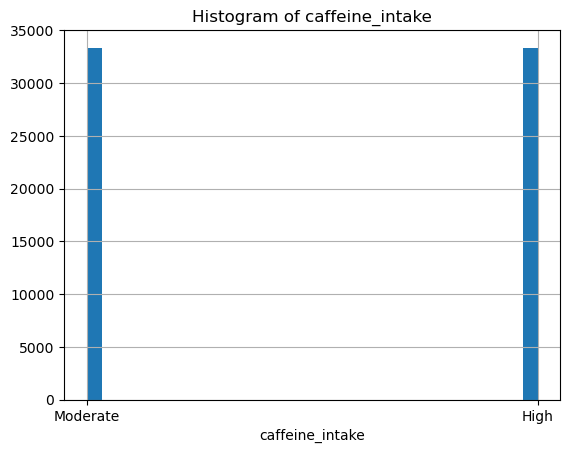

In [254]:
plt.figure()
My_DF["caffeine_intake"].hist(bins=30)
plt.xlabel("caffeine_intake")
plt.title("Histogram of " + "caffeine_intake")
plt.show()

In [255]:
My_DF["caffeine_intake"].value_counts()

caffeine_intake
Moderate    33371
High        33368
Name: count, dtype: int64

In [256]:
col = 'caffeine_intake'
counts = My_DF[col].value_counts()
total_non_null = counts.sum()
values = counts.index.tolist()
probs = (counts / total_non_null).tolist()
null_idx = My_DF[My_DF[col].isnull()].index
My_DF.loc[null_idx, col] = np.random.choice(values, size=len(null_idx), p=probs)
print(My_DF[col].value_counts())

caffeine_intake
Moderate    50030
High        49970
Name: count, dtype: int64


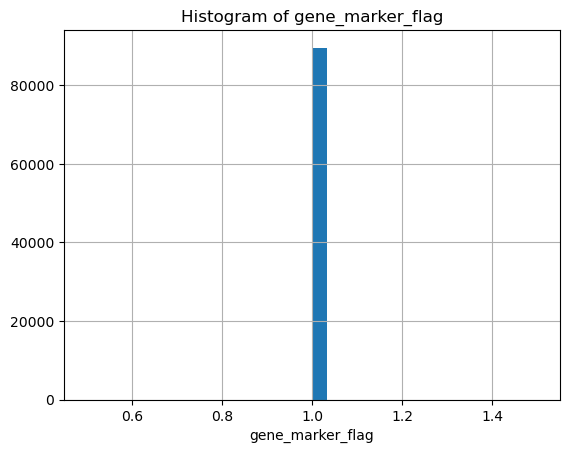

In [257]:
plt.figure()
My_DF["gene_marker_flag"].hist(bins=30)
plt.xlabel("gene_marker_flag")
plt.title("Histogram of " + "gene_marker_flag")
plt.show()

In [258]:
My_DF["gene_marker_flag"].value_counts()

gene_marker_flag
1.0    89526
Name: count, dtype: int64

In [259]:
My_DF['gene_marker_flag']=My_DF['gene_marker_flag'].fillna(1)

In [260]:
My_DF.isnull().sum()

survey_code                 0
age                         0
gender                      0
height                      0
weight                      0
bmi                         0
bmi_estimated               0
bmi_scaled                  0
bmi_corrected               0
waist_size                  0
blood_pressure              0
heart_rate                  0
cholesterol                 0
glucose                     0
insulin                     0
sleep_hours                 0
sleep_quality               0
work_hours                  0
physical_activity           0
daily_steps                 0
calorie_intake              0
sugar_intake                0
alcohol_consumption         0
smoking_level               0
water_intake                0
screen_time                 0
stress_level                0
mental_health_score         0
mental_health_support       0
education_level             0
job_type                    0
occupation                  0
income                      0
diet_type 

In [261]:
My_DF.dtypes

survey_code                   int64
age                           int64
gender                       object
height                      float64
weight                      float64
bmi                         float64
bmi_estimated               float64
bmi_scaled                  float64
bmi_corrected               float64
waist_size                  float64
blood_pressure              float64
heart_rate                  float64
cholesterol                 float64
glucose                     float64
insulin                     float64
sleep_hours                 float64
sleep_quality                object
work_hours                  float64
physical_activity           float64
daily_steps                 float64
calorie_intake              float64
sugar_intake                float64
alcohol_consumption           Int64
smoking_level                object
water_intake                float64
screen_time                 float64
stress_level                  int64
mental_health_score         

In [262]:
My_DF['gender'] = (My_DF['gender'].map({'Male': 1, 'Female': 0}).astype('Int64'))

In [263]:
My_DF["sleep_quality"].value_counts()

sleep_quality
Good         25147
Excellent    25091
Fair         25008
Poor         24754
Name: count, dtype: int64

In [264]:
My_DF['sleep_quality'] = (My_DF['sleep_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}).astype('Int64'))

In [265]:
My_DF["smoking_level"].value_counts()

smoking_level
Light         33437
Non-smoker    33355
Heavy         33208
Name: count, dtype: int64

In [266]:
My_DF['smoking_level'] = (My_DF['smoking_level'].map({'Non-smoker': 0, 'Light': 1, 'Heavy': 2}).astype('int64'))

In [267]:
My_DF["mental_health_support"].value_counts()

mental_health_support
No     50104
Yes    49896
Name: count, dtype: int64

In [268]:
My_DF['mental_health_support'] = My_DF['mental_health_support'].map({'No': 0, 'Yes': 1}).astype('int64')

In [269]:
My_DF["education_level"].value_counts()

education_level
Bachelor       25363
High School    25028
Master         24992
PhD            24617
Name: count, dtype: int64

In [270]:
My_DF['education_level'] = My_DF['education_level'].map({'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}).astype('int64')

In [271]:
My_DF["job_type"].value_counts()

job_type
Labor         16777
Unemployed    16711
Office        16704
Tech          16691
Service       16571
Healthcare    16546
Name: count, dtype: int64

In [272]:
My_DF['job_type'] = My_DF['job_type'].map({'Unemployed': 0, 'Labor': 1, 'Service': 2, 'Office': 3, 'Healthcare': 4, 'Tech': 5}).astype('int64')

In [273]:
My_DF["occupation"].value_counts()

occupation
Doctor      16927
Farmer      16719
Teacher     16661
Artist      16657
Driver      16562
Engineer    16474
Name: count, dtype: int64

In [274]:
My_DF['occupation'] = My_DF['occupation'].map({'Farmer': 0, 'Driver': 1, 'Artist': 2, 'Teacher': 3, 'Engineer': 4, 'Doctor': 5}).astype('int64')

In [275]:
My_DF["diet_type"].value_counts()

diet_type
Vegan         25122
Omnivore      25089
Vegetarian    25025
Keto          24764
Name: count, dtype: int64

In [276]:
My_DF['diet_type'] = My_DF['diet_type'].map({'Omnivore': 0, 'Vegetarian': 1, 'Vegan': 2, 'Keto': 3}).astype('int64')

In [277]:
My_DF["exercise_type"].value_counts()

exercise_type
Strength    33713
Cardio      33285
Mixed       33002
Name: count, dtype: int64

In [278]:
My_DF['exercise_type'] = My_DF['exercise_type'].map({'Mixed': 0, 'Cardio': 1, 'Strength': 2}).astype('int64')


In [279]:
My_DF["device_usage"].value_counts()

device_usage
High        33562
Moderate    33241
Low         33197
Name: count, dtype: int64

In [280]:
My_DF['device_usage'] = My_DF['device_usage'].map({'Low': 0, 'Moderate': 1, 'High': 2}).astype('int64')

In [281]:
My_DF["healthcare_access"].value_counts()

healthcare_access
Good        33428
Moderate    33295
Poor        33277
Name: count, dtype: int64

In [282]:
My_DF['healthcare_access'] = My_DF['healthcare_access'].map({'Poor': 0, 'Moderate': 1, 'Good': 2}).astype('int64')

In [283]:
My_DF["insurance"].value_counts()

insurance
Yes    50121
No     49879
Name: count, dtype: int64

In [284]:
My_DF['insurance'] = My_DF['insurance'].map({'No': 0, 'Yes': 1}).astype('int64')

In [285]:
My_DF["sunlight_exposure"].value_counts()

sunlight_exposure
Low         33468
Moderate    33451
High        33081
Name: count, dtype: int64

In [286]:
My_DF['sunlight_exposure'] = My_DF['sunlight_exposure'].map({'Low': 0, 'Moderate': 1, 'High': 2}).astype('int64')

In [287]:
My_DF["caffeine_intake"].value_counts()

caffeine_intake
Moderate    50030
High        49970
Name: count, dtype: int64

In [288]:
My_DF['caffeine_intake'] = My_DF['caffeine_intake'].map({'Moderate': 0, 'High': 1}).astype('int64')

In [289]:
My_DF["family_history"].value_counts()

family_history
Yes    50055
No     49945
Name: count, dtype: int64

In [290]:
My_DF['family_history'] = My_DF['family_history'].map({'No': 0, 'Yes': 1}).astype('int64')

In [291]:
My_DF["pet_owner"].value_counts()

pet_owner
No     50153
Yes    49847
Name: count, dtype: int64

In [292]:
My_DF['pet_owner'] = My_DF['pet_owner'].map({'No': 0, 'Yes': 1}).astype('int64')

In [293]:
My_DF["target"].value_counts()

target
healthy     70097
diseased    29903
Name: count, dtype: int64

In [294]:
My_DF['target'] = My_DF['target'].map({'healthy': 1, 'diseased': 0}).astype('int64')

In [295]:
My_DF.dtypes

survey_code                   int64
age                           int64
gender                        Int64
height                      float64
weight                      float64
bmi                         float64
bmi_estimated               float64
bmi_scaled                  float64
bmi_corrected               float64
waist_size                  float64
blood_pressure              float64
heart_rate                  float64
cholesterol                 float64
glucose                     float64
insulin                     float64
sleep_hours                 float64
sleep_quality                 Int64
work_hours                  float64
physical_activity           float64
daily_steps                 float64
calorie_intake              float64
sugar_intake                float64
alcohol_consumption           Int64
smoking_level                 int64
water_intake                float64
screen_time                 float64
stress_level                  int64
mental_health_score         

In [298]:
X = My_DF.drop('target',axis=1)
y = My_DF['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [301]:
print("\n[Model 1] Logistic Regression...")
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr) * 100
print(f"Accuracy: {acc_lr:.2f}%")
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_lr, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")


[Model 1] Logistic Regression...
Accuracy: 81.56%
Confusion Matrix:
 [[ 3698  2259]
 [ 1430 12613]]
Class 0 F1 Score: 0.6672079386558413
Class 1 F1 Score: 0.872419159605741


C:\Users\dell\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
print("\n[Model 2] Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Accuracy: {acc_rf:.2f}%")

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_rf, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")



[Model 2] Random Forest...
Accuracy: 79.37%
Confusion Matrix:
 [[ 3714  2243]
 [ 1350 12693]]
Class 0 F1 Score: 0.5624602332979851
Class 1 F1 Score: 0.8650310762185149


In [302]:
print("\n[Model 3] XGBoost (Gradient Boosting)...")
xgb_model = xgb.XGBClassifier(
    n_estimators=2000, 
    learning_rate=0.1, 
    max_depth=5, 
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100
print(f"Accuracy: {acc_xgb:.2f}%")
cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_xgb, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")


[Model 3] XGBoost (Gradient Boosting)...
Accuracy: 86.74%
Confusion Matrix:
 [[ 3698  2259]
 [ 1430 12613]]
Class 0 F1 Score: 0.7696717040125065
Class 1 F1 Score: 0.906901635891315


In [306]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print("Class Distribution AFTER SMOTE (Training Set):")
y_train_smote.value_counts()

Class Distribution AFTER SMOTE (Training Set):


target
1    56026
0    56026
Name: count, dtype: int64

In [307]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [313]:
lr_model = LogisticRegression(max_iter=3000, C=0.1, random_state=42)
lr_model.fit(X_train_scaled, y_train_smote)
y_pred_lr = lr_model.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr) * 100
print(f"Accuracy: {acc_lr:.2f}%")
cm = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_lr, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")

Accuracy: 84.19%
Confusion Matrix:
 [[ 4985   972]
 [ 2189 11854]]
Class 0 F1 Score: 0.7592719518696215
Class 1 F1 Score: 0.8823551304477278


In [312]:
rf_model = RandomForestClassifier(
    n_estimators=300, 
    max_depth=20, 
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf) * 100
print(f"Accuracy: {acc_rf:.2f}%")

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_rf, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")

Accuracy: 81.97%
Confusion Matrix:
 [[ 3413  2544]
 [ 1061 12982]]
Class 0 F1 Score: 0.6543955517208321
Class 1 F1 Score: 0.8780817748317494


In [311]:
xgb_model = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=8, 
    min_child_weight=1,subsample=0.9,colsample_bytree=0.9,gamma=0.1,
    eval_metric='logloss',random_state=42)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_xgb = xgb_model.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb) * 100
print(f"Accuracy: {acc_xgb:.2f}%")

cm = confusion_matrix(y_test, y_pred_xgb)
print("Confusion Matrix:\n", cm)
f1 = f1_score(y_test, y_pred_xgb, average=None)
for i, score in enumerate(f1):
    print(f"Class {i} F1 Score: {score}")

Accuracy: 86.98%
Confusion Matrix:
 [[ 4315  1642]
 [  963 13080]]
Class 0 F1 Score: 0.7681352914997774
Class 1 F1 Score: 0.9094385537980184
